In [ ]:
from prophet import Prophet
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
pip install pandas openpyxl prophet matplotlib

In [ ]:
df=pd.read_csv("/content/課金額 - シート1 (1).csv")

In [ ]:

# 列名を表示
print(df.columns)

Index(['年月', '課金件数', '課金者数', '課金額', 'arppu'], dtype='object')


In [ ]:
# カンマを除去し、文字列から数値（float）へ変換
df['課金額'] = df['課金額'].astype(str).str.replace(',', '').astype(float)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8tp8v9iu/0qn3n8tx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8tp8v9iu/idvigs7f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54075', 'data', 'file=/tmp/tmp8tp8v9iu/0qn3n8tx.json', 'init=/tmp/tmp8tp8v9iu/idvigs7f.json', 'output', 'file=/tmp/tmp8tp8v9iu/prophet_model9ehn2prd/prophet_model-20250425100328.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
10:03:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:03:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

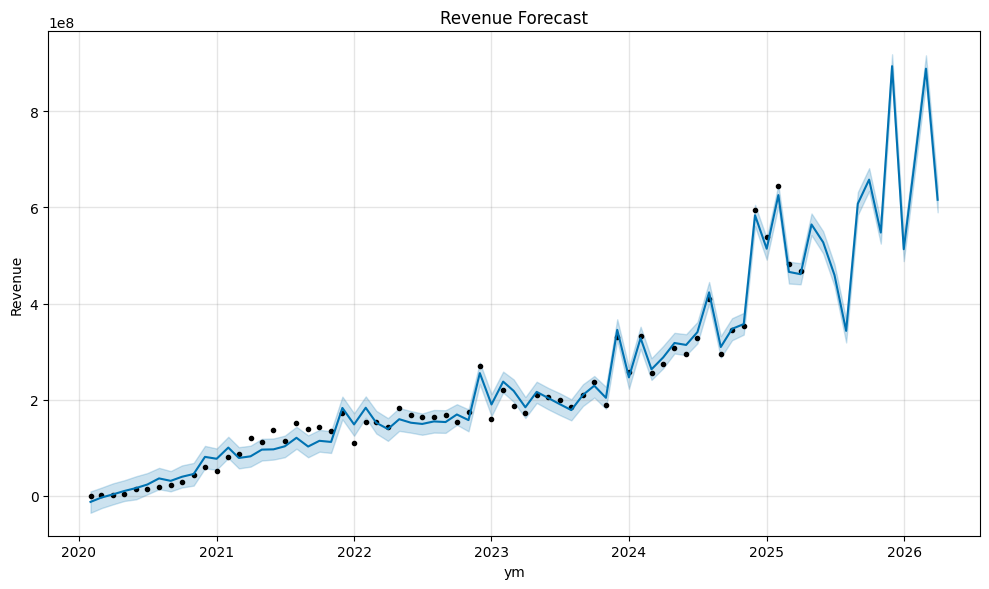

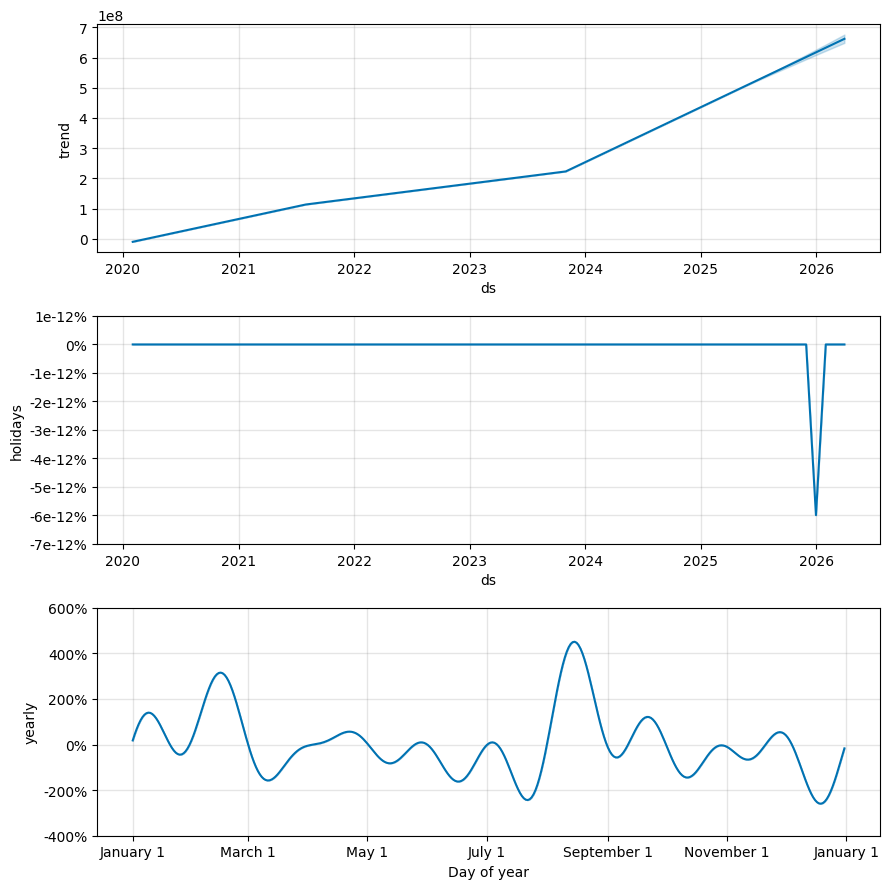

In [ ]:
# 「年月」を日付形式に変換（1日を付け足す）
df['ds'] = pd.to_datetime(df['年月'].astype(str) + '/01')

# Prophet用に列名を統一
df['y'] = df['課金額']
df = df[['ds', 'y']].sort_values('ds')

# --- 2. イベントの設定（holidays） ---
years = range(2020, 2026)

christmas = pd.DataFrame({
    'holiday': 'christmas',
    'ds': pd.to_datetime([f'{year}-12-25' for year in years]),
    'lower_window': 0,
    'upper_window': 0
})

new_year_end = pd.DataFrame({
    'holiday': 'year_end',
    'ds': pd.to_datetime(
        [f'{year}-12-30' for year in years] +
        [f'{year}-12-31' for year in years]
    ),
    'lower_window': 0,
    'upper_window': 0
})

anniversary = pd.DataFrame({
    'holiday': 'anniversary',
    'ds': pd.to_datetime([f'{year}-02-27' for year in years]),
    'lower_window': 0,
    'upper_window': 0
})

half_anniversary = pd.DataFrame({
    'holiday': 'half_anniversary',
    'ds': pd.to_datetime([f'{year}-08-27' for year in years]),
    'lower_window': 0,
    'upper_window': 0
})

# holidays統合
holidays = pd.concat([christmas, new_year_end, anniversary, half_anniversary])

# --- 3. Prophetモデルの定義と学習 ---
model = Prophet(
    holidays=holidays,
    seasonality_mode='multiplicative',  # 変動が大きいため
    yearly_seasonality=True             # 年次季節性を考慮
)

# モデル学習
model.fit(df)

# --- 4. 予測用データフレーム作成（未来12ヶ月） ---
future = model.make_future_dataframe(periods=12, freq='M')

# 予測実行
forecast = model.predict(future)

# --- 5. 予測結果の可視化 ---
fig1 = model.plot(forecast)
plt.title("Revenue Forecast")
plt.xlabel("ym")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# --- 6. トレンド・季節性・イベントの影響を可視化 ---
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()